In [96]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Trabalho de Avaliação - Projeto Titanic  
**Módulo:** Análise de Dados  
**Duração:** 2 semanas  
**Formato de Entrega:** Jupyter Notebook ou PDF com código e interpretações

---

## 📁 Dataset e Contexto

Neste exercício, será utilizada a base de dados do desastre do Titanic, amplamente conhecida na comunidade de ciência de dados.

- `train.csv` → Contém os dados com o desfecho (`Survived`) conhecido.

### 🔑 Dicionário de Dados

| Variável      | Descrição                                    | Notas                                              |
|---------------|----------------------------------------------|-----------------------------------------------------|
| `Survived`    | Sobreviveu (0 = Não, 1 = Sim)                | **Target** da análise preditiva                     |
| `Pclass`      | Classe do bilhete (1 = 1ª, 2 = 2ª, 3 = 3ª)    | Indicador de estatuto socioeconómico               |
| `Sex`         | Sexo                                         | `male`, `female`                                   |
| `Age`         | Idade em anos                                | Fracionária se < 1. Estimada com `.5` se necessário|
| `SibSp`       | Nº de irmãos/cônjuges a bordo                |                                                    |
| `Parch`       | Nº de pais/filhos a bordo                    |                                                    |
| `Ticket`      | Nº do bilhete                                |                                                    |
| `Fare`        | Valor pago pelo bilhete                      |                                                    |
| `Cabin`       | Número da cabine                             | Muitos valores em falta                            |
| `Embarked`    | Porto de embarque (`C`, `Q`, `S`)            | Cherbourg, Queenstown, Southampton                 |

---

## 🎯 Objetivos do Trabalho

O trabalho pretende avaliar:
- Capacidade de realizar uma análise exploratória detalhada (EDA)
- Domínio na criação de variáveis e tratamento de dados
- Clareza na interpretação e comunicação dos resultados

---

## 📋 Tarefas Obrigatórias

### 1. Análise Exploratória (EDA) - *[60%]*

- Apresente estatísticas descritivas das variáveis numéricas (`Age`, `Fare`, `SibSp`, `Parch`).
- Identifique e quantifique valores em falta.
- Qual a distribuição da idade (Age) dos passageiros? Há indícios de assimetria (skewness)?
- Compare o valor médio e mediano da tarifa (Fare) entre sobreviventes e não sobreviventes. Que grupo pagou mais, em média?
- Existe correlação entre Fare, Pclass e Survived?
- Qual o porto de embarque mais frequente? Há relação entre o porto de embarque (Embarked) e a taxa de sobrevivência?
- Há alguma diferença clara no número de sobreviventes por classe (Pclass) e sexo (Sex), combinados?
- Qual é a taxa de sobrevivência de passageiros que viajaram sozinhos (SibSp == 0 e Parch == 0) comparada aos que estavam com familiares?
- Existe relação entre o tamanho da família a bordo (FamilySize = SibSp + Parch + 1) e a taxa de sobrevivência?
- Verifique se passageiros com bilhetes mais caros estavam mais concentrados em determinada cabine ou local de embarque.
- Sabemos que Cabin tem muitos valores nulos. Existe algum padrão? Estão mais ausentes em determinada classe (Pclass)?
- Analise se há passageiros com tarifa 0. O que isso pode indicar? Devem ser removidos?
- Crie gráficos que respondam às perguntas:
  - A taxa de sobrevivência varia consoante a **classe (`Pclass`)**?
  - Qual o papel do **sexo (`Sex`)** na sobrevivência?
  - Crianças (< 12 anos) tiveram maior taxa de sobrevivência?

### 2. Engenharia de Variáveis - *[15%]*

- Crie uma variável `FamilySize = SibSp + Parch`.
- Extraia o **título** do passageiro a partir da coluna `Name` (ex: `Mr`, `Mrs`, `Miss`).
- Justifique a relevância destas variáveis para a análise.

### 3. Pré-processamento - *[10%]*

- Proponha estratégias de codificação para variáveis categóricas (`Sex`, `Embarked`, `Pclass`).
- Explique como trataria os valores ausentes de forma fundamentada.

- Escolha 3 variáveis e discuta como, combinadas, podem indicar a probabilidade de sobrevivência

### 4. Desafio Interpretativo Avançado - *[15%]*

- Há variáveis com potencial de falsa correlação? Justifique a sua resposta

### Importe as bibliotecas que entender necessárias

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df = pd.read_csv(r"/content/drive/MyDrive/Análise de dados/Bases de Dados/Titanic.csv")

In [100]:
df.head(7)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S


In [185]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   PassengerId      891 non-null    int64   
 1   Survived         891 non-null    int64   
 2   Pclass           891 non-null    int64   
 3   Name             891 non-null    object  
 4   Sex              891 non-null    object  
 5   Age              891 non-null    Int64   
 6   SibSp            891 non-null    int64   
 7   Parch            891 non-null    int64   
 8   Ticket           891 non-null    object  
 9   Fare             891 non-null    float64 
 10  Cabin            204 non-null    object  
 11  Embarked         891 non-null    object  
 12  Fare_Binned      891 non-null    category
 13  Tem_SibSp        891 non-null    int64   
 14  Tem_Parch        891 non-null    int64   
 15  Age_Binned       891 non-null    category
 16  Sex_bin          891 non-null    int64   
 1

In [186]:
missing_data = df.isnull().sum()

In [ ]:
# Calcular a percentagem de valores nulos
missing_percentage = (missing_data / len(df)) * 100

# Criar DataFrame com as informações
missing_info = pd.DataFrame({
    'Valores Nulos': missing_data,
    'Percentagem': missing_percentage
})

# Arredondar a percentagem a 2 casas decimais
missing_info['Percentagem'] = missing_info['Percentagem'].round(2)

In [103]:
(missing_info['Percentagem'])

,Percentagem
PassengerId,0.00
Survived,0.00
Pclass,0.00
Name,0.00
Sex,0.00
Age,19.87
SibSp,0.00
Parch,0.00
Ticket,0.00
Fare,0.00


In [104]:
age_stats = df['Age'].describe()
print(age_stats)

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64


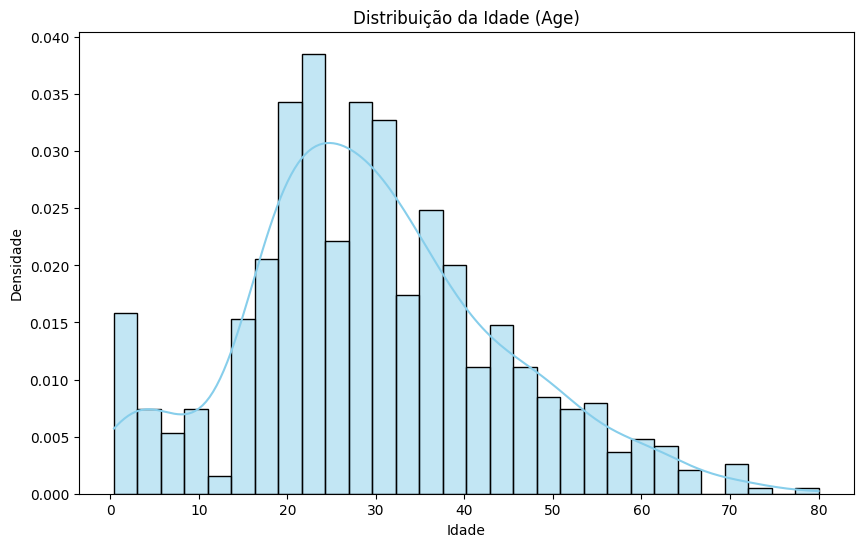

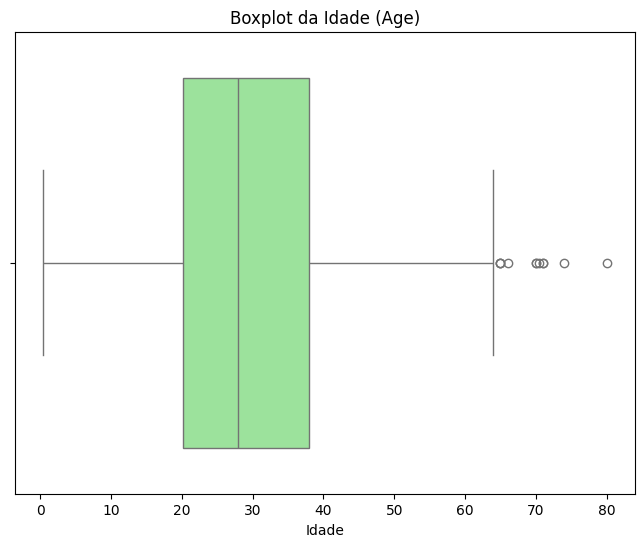

In [105]:
# Histograma da variável 'Age'
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, bins=30, color='skyblue', stat='density')
plt.title('Distribuição da Idade (Age)')
plt.xlabel('Idade')
plt.ylabel('Densidade')
plt.show()

# Boxplot da variável 'Age' para verificar outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Age'], color='lightgreen')
plt.title('Boxplot da Idade (Age)')
plt.xlabel('Idade')
plt.show()

Índices dos outliers identificados:
Index([33, 54, 96, 116, 280, 456, 493, 630, 672, 745, 851], dtype='int64')

Tabela com os outliers identificados:
      Age
33   66.0
54   65.0
96   71.0
116  70.5
280  65.0
456  65.0
493  71.0
630  80.0
672  70.0
745  70.0
851  74.0


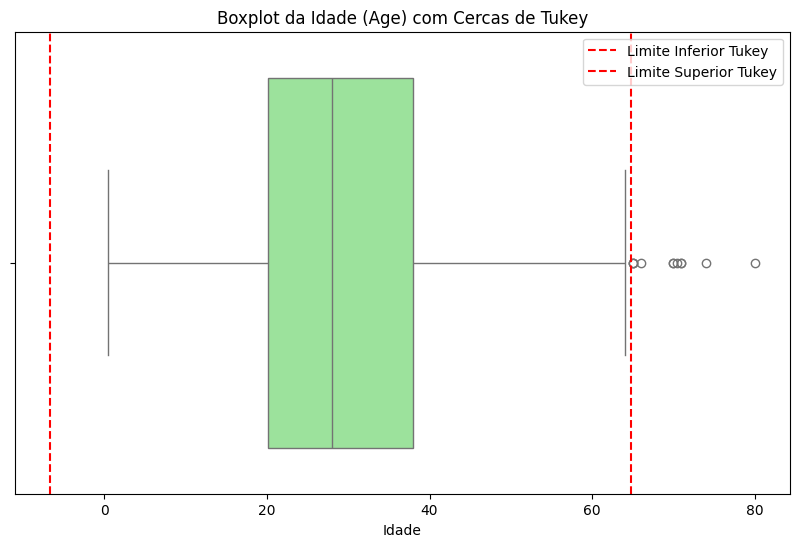

In [106]:
# Calcular o IQR da variável 'Age'
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

# Definir os limites superior e inferior das cercas de Tukey
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identificar os outliers
outliers = df[(df['Age'] < lower_bound) | (df['Age'] > upper_bound)]

# Exibir os índices dos outliers
print("Índices dos outliers identificados:")
print(outliers.index)

# Exibir os outliers na tabela
print("\nTabela com os outliers identificados:")
print(outliers[['Age']])

# Boxplot com cercas de Tukey visíveis
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Age'], color='lightgreen')

# Adicionar as linhas tracejadas para os limites das cercas de Tukey
plt.axvline(x=lower_bound, color='red', linestyle='--', label='Limite Inferior Tukey')
plt.axvline(x=upper_bound, color='red', linestyle='--', label='Limite Superior Tukey')

# Adicionar título e rótulos
plt.title('Boxplot da Idade (Age) com Cercas de Tukey')
plt.xlabel('Idade')
plt.legend()

plt.show()

In [107]:
from scipy.stats import kurtosis, skew

# Calcular a assimetria (skewness) e a curtose
age_skewness = skew(df['Age'].dropna())
age_kurtosis = kurtosis(df['Age'].dropna())

# Exibir os resultados
print(f"Assimetria (Skewness) da variável 'Age': {age_skewness:.2f}")
print(f"Curtose (Kurtosis) da variável 'Age': {age_kurtosis:.2f}")

Assimetria (Skewness) da variável 'Age': 0.39
Curtose (Kurtosis) da variável 'Age': 0.17


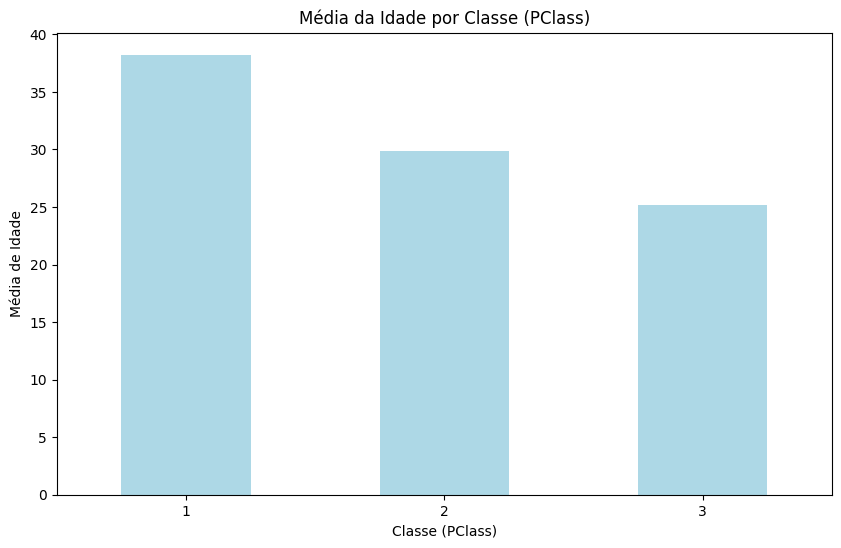

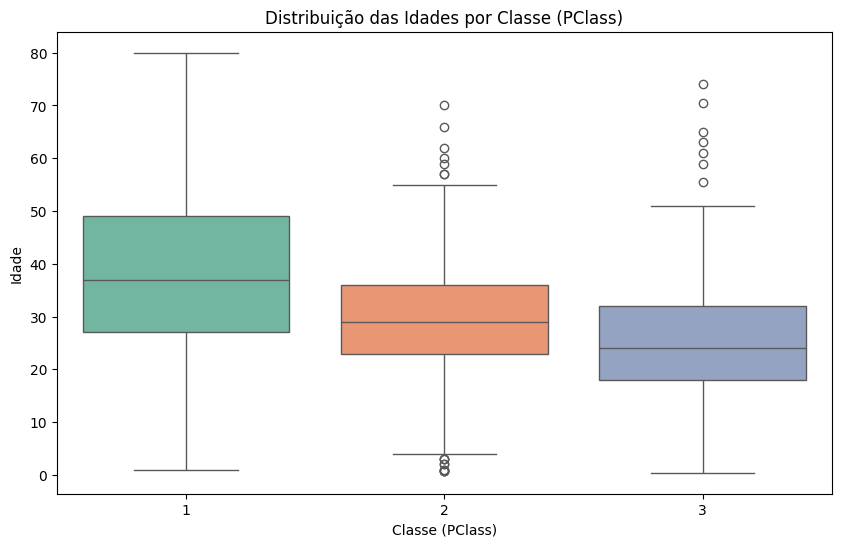

In [108]:
# Gráfico de barras com a média das idades por PClass
plt.figure(figsize=(10, 6))
mean_age_by_pclass = df.groupby('Pclass')['Age'].mean()
mean_age_by_pclass.plot(kind='bar', color='lightblue')

# Ajustar o gráfico
plt.title('Média da Idade por Classe (PClass)')
plt.xlabel('Classe (PClass)')
plt.ylabel('Média de Idade')
plt.xticks(rotation=0)
plt.show()

# Boxplot para visualizar a distribuição das idades por PClass
plt.figure(figsize=(10, 6))
sns.boxplot(x='Pclass', y='Age', hue='Pclass', legend=False, data=df, palette='Set2')

# Ajustar o gráfico
plt.title('Distribuição das Idades por Classe (PClass)')
plt.xlabel('Classe (PClass)')
plt.ylabel('Idade')
plt.show()

In [109]:
# Calcular a mediana de 'Age' por 'Pclass'
median_age_by_pclass = df.groupby('Pclass')['Age'].median()

# Exibir as medianas para cada classe
print("Mediana de 'Age' por 'Pclass':")
print(median_age_by_pclass)

Mediana de 'Age' por 'Pclass':
Pclass
1    37.0
2    29.0
3    24.0
Name: Age, dtype: float64


In [110]:
# Preencher os valores ausentes de 'Age' com a mediana correspondente à 'Pclass'
df['Age'] = df.apply(
    lambda row: median_age_by_pclass[row['Pclass']] if pd.isnull(row['Age']) else row['Age'], axis=1
)

# Verificar se existem mais valores ausentes
missing_after_imputation = df['Age'].isnull().sum()
print(f"\nValores ausentes de 'Age' após imputação: {missing_after_imputation}")


Valores ausentes de 'Age' após imputação: 0


In [111]:
df.isnull().sum()



,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [112]:
# Verificar a presença de NaN na coluna 'Age'
print(f"Valores NaN antes da conversão: {df['Age'].isnull().sum()}")

# Arredondar os valores da coluna 'Age' para inteiros e, em seguida, converter para 'Int64'
df['Age'] = df['Age'].round().astype('Int64')

# Verificar o tipo de dado após a conversão
print(f"Tipo de dado de 'Age' após conversão: {df['Age'].dtype}")

# Verificar novamente a presença de NaN na coluna 'Age' após a conversão
print(f"Valores NaN após a conversão: {df['Age'].isnull().sum()}")

Valores NaN antes da conversão: 0
Tipo de dado de 'Age' após conversão: Int64
Valores NaN após a conversão: 0


In [113]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,NaN,S


In [114]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,Int64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [115]:
# Verificar a frequência total e a percentagem de cada valor na coluna 'Embarked'
embarked_counts = df['Embarked'].value_counts()
embarked_percentage = df['Embarked'].value_counts(normalize=True) * 100

# Criar um DataFrame com as frequências e percentagens
embarked_summary = pd.DataFrame({'Frequência': embarked_counts, 'Percentagem': embarked_percentage})

# Exibir o resumo
print(embarked_summary)

          Frequência  Percentagem
Embarked                         
S                644    72.440945
C                168    18.897638
Q                 77     8.661417


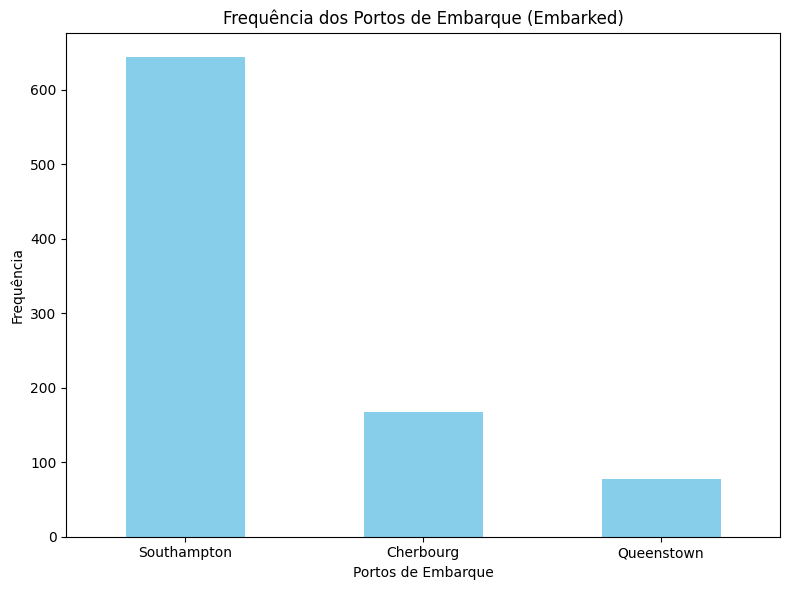

In [116]:
# Substituir os valores 'S', 'C', 'Q' por seus nomes completos
df['Embarked'] = df['Embarked'].replace({'S': 'Southampton', 'C': 'Cherbourg', 'Q': 'Queenstown'})

# Calcular a frequência de cada valor na coluna 'Embarked'
embarked_counts = df['Embarked'].value_counts()

# Criar gráfico de barras
plt.figure(figsize=(8, 6))
embarked_counts.plot(kind='bar', color='skyblue')

# Adicionar título e rótulos
plt.title('Frequência dos Portos de Embarque (Embarked)')
plt.xlabel('Portos de Embarque')
plt.ylabel('Frequência')
plt.xticks(rotation=0)  # Manter os rótulos do eixo X legíveis

# Exibir o gráfico
plt.tight_layout()
plt.show()

In [117]:
# Filtrar as linhas onde a coluna 'Embarked' tem valor nulo
missing_embarked = df[df['Embarked'].isnull()]

# Exibir os dois primeiros registros com valores ausentes em 'Embarked'
missing_embarked.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62,0,0,113572,80.0,B28,NaN


In [118]:
# Identificar o número de ticket das linhas com valores nulos na coluna 'Embarked'
ticket_with_missing_embarked = df[df['Embarked'].isnull()]['Ticket'].iloc[0]

# Verificar outros registros com o mesmo número de ticket
same_ticket_records = df[df['Ticket'] == ticket_with_missing_embarked]

# Exibir os registros com o mesmo número de ticket
print(same_ticket_records[['PassengerId', 'Ticket', 'Embarked']])

     PassengerId  Ticket Embarked
61            62  113572      NaN
829          830  113572      NaN


In [119]:
# Calcular a moda (valor mais frequente) da coluna 'Embarked'
embarked_mode = df['Embarked'].mode()[0]

# Substituir os valores nulos de 'Embarked' pela moda
df['Embarked'] = df['Embarked'].fillna(embarked_mode)

# Verificar se ainda existem valores nulos em 'Embarked'
print(f"Valores nulos restantes em 'Embarked': {df['Embarked'].isnull().sum()}")

Valores nulos restantes em 'Embarked': 0


In [ ]:
df.isnull().sum()

In [120]:
# Verificar a frequência total e a percentagem de cada valor na coluna 'Embarked'
embarked_counts = df['Embarked'].value_counts()
embarked_percentage = df['Embarked'].value_counts(normalize=True) * 100

# Criar um DataFrame com as frequências e percentagens
embarked_summary = pd.DataFrame({'Frequência': embarked_counts, 'Percentagem': embarked_percentage})

# Exibir o resumo
print(embarked_summary)

             Frequência  Percentagem
Embarked                            
Southampton         646    72.502806
Cherbourg           168    18.855219
Queenstown           77     8.641975


In [121]:
duplicados = df.duplicated()
print(f"Número de registos duplicados: {duplicados.sum()}")


Número de registos duplicados: 0


In [122]:
# Número de valores únicos por coluna
valores_unicos = df.nunique().sort_values(ascending=False)
print("Número de valores únicos por coluna:")
print(valores_unicos)


Número de valores únicos por coluna:
PassengerId    891
Name           891
Ticket         681
Fare           248
Cabin          147
Age             71
SibSp            7
Parch            7
Embarked         3
Pclass           3
Survived         2
Sex              2
dtype: int64


Top 10 bilhetes mais frequentes:
         Ticket  Frequência
0        347082           7
1          1601           7
2      CA. 2343           7
3       3101295           6
4       CA 2144           6
5        347088           6
6        382652           5
7  S.O.C. 14879           5
8        113760           4
9         19950           4


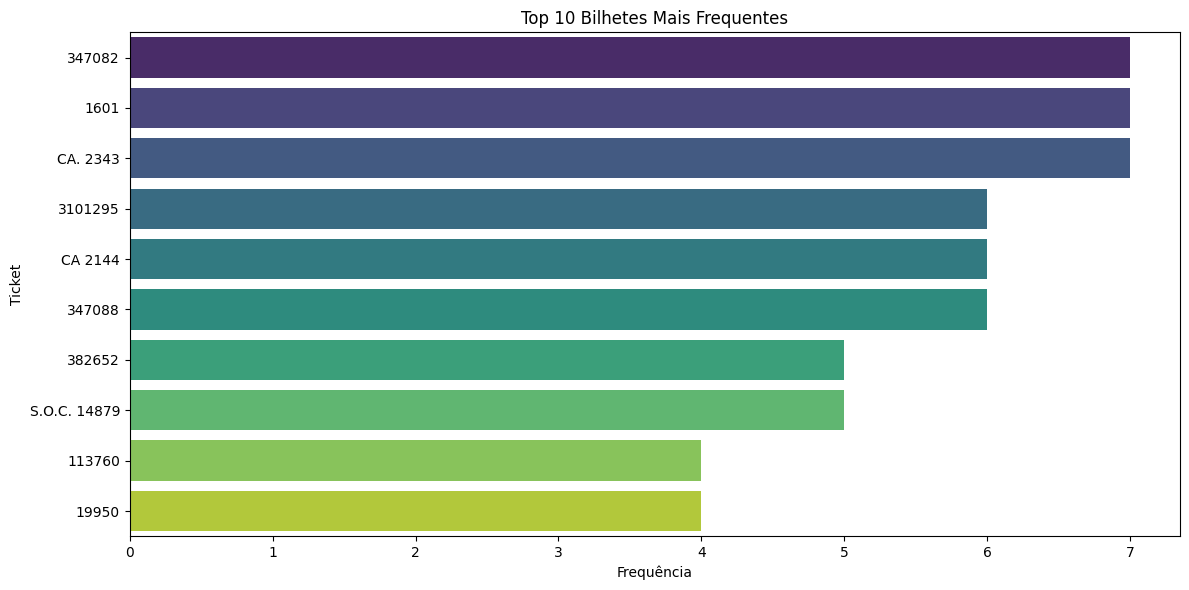

In [123]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tabela de frequência da variável 'Ticket'
frequencia_ticket = df['Ticket'].value_counts().reset_index()
frequencia_ticket.columns = ['Ticket', 'Frequência']

# Mostrar os 10 bilhetes mais comuns
print("Top 10 bilhetes mais frequentes:")
print(frequencia_ticket.head(10))

# Gráfico de barras com os 10 bilhetes mais comuns
plt.figure(figsize=(12,6))
sns.barplot(x='Frequência', y='Ticket', hue='Ticket',data=frequencia_ticket.head(10), palette='viridis', legend=False)
plt.title('Top 10 Bilhetes Mais Frequentes')
plt.xlabel('Frequência')
plt.ylabel('Ticket')
plt.tight_layout()
plt.show()


In [124]:
# Certifica-te que o valor é string, pois a coluna Ticket é do tipo object
registos_ticket_347082 = df[df['Ticket'] == 'CA. 2343']

# Mostrar os resultados
print(f"Total de registos com Ticket = 347082: {len(registos_ticket_347082)}")
display(registos_ticket_347082)


Total de registos com Ticket = 347082: 7


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0,3,"Sage, Master. Thomas Henry",male,24,8,2,CA. 2343,69.55,NaN,Southampton
180,181,0,3,"Sage, Miss. Constance Gladys",female,24,8,2,CA. 2343,69.55,NaN,Southampton
201,202,0,3,"Sage, Mr. Frederick",male,24,8,2,CA. 2343,69.55,NaN,Southampton
324,325,0,3,"Sage, Mr. George John Jr",male,24,8,2,CA. 2343,69.55,NaN,Southampton
792,793,0,3,"Sage, Miss. Stella Anna",female,24,8,2,CA. 2343,69.55,NaN,Southampton
846,847,0,3,"Sage, Mr. Douglas Bullen",male,24,8,2,CA. 2343,69.55,NaN,Southampton
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,24,8,2,CA. 2343,69.55,NaN,Southampton


In [125]:
# Filtrar linhas que contenham 'SAGE' na coluna Name (sem diferenciar maiúsculas/minúsculas)
filtro_sage = df[df['Name'].str.contains('SAGE', case=False, na=False)]

# Mostrar o resultado
print(f"Total de registos com 'SAGE' no nome: {len(filtro_sage)}")
display(filtro_sage)


Total de registos com 'SAGE' no nome: 8


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0,3,"Sage, Master. Thomas Henry",male,24,8,2,CA. 2343,69.55,NaN,Southampton
180,181,0,3,"Sage, Miss. Constance Gladys",female,24,8,2,CA. 2343,69.55,NaN,Southampton
201,202,0,3,"Sage, Mr. Frederick",male,24,8,2,CA. 2343,69.55,NaN,Southampton
324,325,0,3,"Sage, Mr. George John Jr",male,24,8,2,CA. 2343,69.55,NaN,Southampton
641,642,1,1,"Sagesser, Mlle. Emma",female,24,0,0,PC 17477,69.30,B35,Cherbourg
792,793,0,3,"Sage, Miss. Stella Anna",female,24,8,2,CA. 2343,69.55,NaN,Southampton
846,847,0,3,"Sage, Mr. Douglas Bullen",male,24,8,2,CA. 2343,69.55,NaN,Southampton
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,24,8,2,CA. 2343,69.55,NaN,Southampton


📊 Estatísticas Descritivas da variável 'Fare':
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

🔎 Limites de Tukey para detecção de outliers:
Q1 (25%): 7.91
Q3 (75%): 31.00
IQR: 23.09
Limite inferior: -26.72
Limite superior: 65.63
Total de outliers: 116


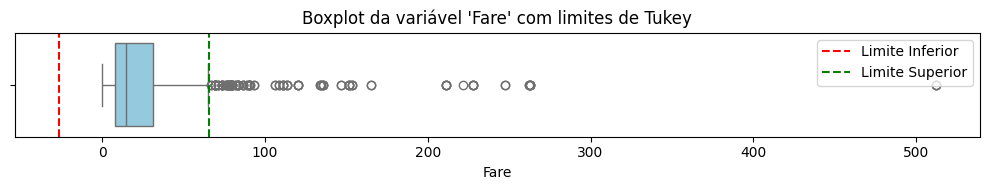


🧪 Teste de normalidade (D’Agostino-Pearson):
Estatística do teste: 904.5873
Valor-p: 0.0000
➡️ Rejeitamos H0: a variável 'Fare' **não segue distribuição normal**.


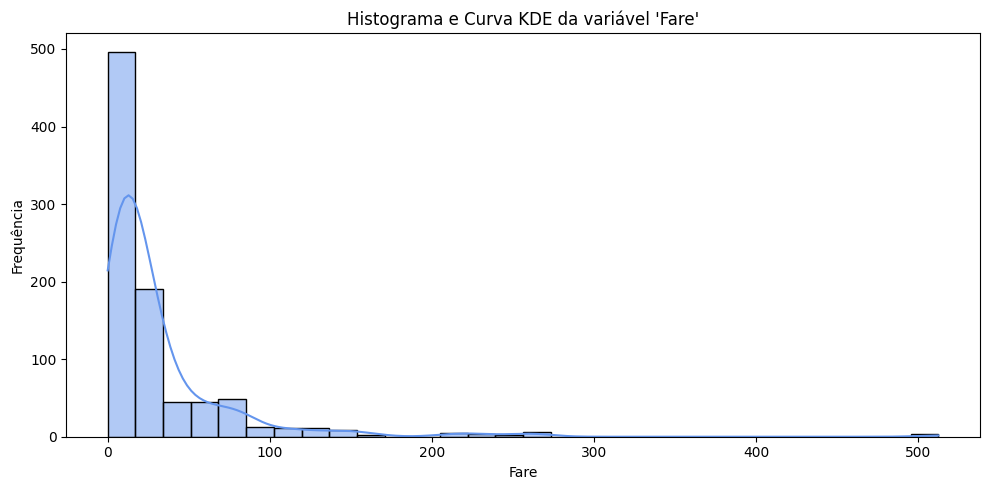


📈 Assimetria (Skewness) e Curtose:
Skewness: 4.79 (direita)
Curtose: 33.40 (leptocúrtica)


In [126]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Filtrar a variável
fare = df['Fare'].dropna()

# 1. Estatística Descritiva
print("📊 Estatísticas Descritivas da variável 'Fare':")
print(fare.describe())

# 2. Detecção de Outliers com limites de Tukey
Q1 = fare.quantile(0.25)
Q3 = fare.quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = fare[(fare < limite_inferior) | (fare > limite_superior)]

print("\n🔎 Limites de Tukey para detecção de outliers:")
print(f"Q1 (25%): {Q1:.2f}")
print(f"Q3 (75%): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Limite inferior: {limite_inferior:.2f}")
print(f"Limite superior: {limite_superior:.2f}")
print(f"Total de outliers: {len(outliers)}")

# 3. Boxplot com limites de Tukey visualizados
plt.figure(figsize=(10, 2))
sns.boxplot(x=fare, color='skyblue')
plt.axvline(limite_inferior, color='red', linestyle='--', label='Limite Inferior')
plt.axvline(limite_superior, color='green', linestyle='--', label='Limite Superior')
plt.title("Boxplot da variável 'Fare' com limites de Tukey")
plt.legend()
plt.tight_layout()
plt.show()

# 4. Verificação da Normalidade (teste de Shapiro-Wilk ou D’Agostino-Pearson para n > 500)
stat, p = stats.normaltest(fare)

print("\n🧪 Teste de normalidade (D’Agostino-Pearson):")
print(f"Estatística do teste: {stat:.4f}")
print(f"Valor-p: {p:.4f}")
if p < 0.05:
    print("➡️ Rejeitamos H0: a variável 'Fare' **não segue distribuição normal**.")
else:
    print("✅ Não rejeitamos H0: a variável 'Fare' **pode seguir distribuição normal**.")

# 5. Histograma com KDE
plt.figure(figsize=(10, 5))
sns.histplot(fare, kde=True, color='cornflowerblue', bins=30)
plt.title("Histograma e Curva KDE da variável 'Fare'")
plt.xlabel("Fare")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

# 6. Skewness e Curtose
skew = fare.skew()
kurt = fare.kurtosis()

print("\n📈 Assimetria (Skewness) e Curtose:")
print(f"Skewness: {skew:.2f} ({'direita' if skew > 0 else 'esquerda' if skew < 0 else 'simétrica'})")
print(f"Curtose: {kurt:.2f} ({'leptocúrtica' if kurt > 0 else 'platicúrtica' if kurt < 0 else 'mesocúrtica'})")


In [127]:
# Ver o valor máximo
valor_max_fare = df['Fare'].max()
print(f"🎯 Valor máximo de Fare: {valor_max_fare}")


🎯 Valor máximo de Fare: 512.3292


In [128]:
# Filtrar as linhas onde Fare é igual ao valor máximo
registo_outlier_fare = df[df['Fare'] == valor_max_fare]

# Mostrar o registo completo
print(f"🔎 Registos com Fare = {valor_max_fare}:")
display(registo_outlier_fare)  # Usa display se estiveres em Jupyter/Colab


🔎 Registos com Fare = 512.3292:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
258,259,1,1,"Ward, Miss. Anna",female,35,0,0,PC 17755,512.3292,NaN,Cherbourg
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36,0,1,PC 17755,512.3292,B51 B53 B55,Cherbourg
737,738,1,1,"Lesurer, Mr. Gustave J",male,35,0,0,PC 17755,512.3292,B101,Cherbourg


In [129]:
# Filtrar os passageiros da 1ª classe
classe_1 = df[df['Pclass'] == 1]
media_fare = classe_1['Fare'].mean()
mediana_fare = classe_1['Fare'].median()
max_fare = classe_1['Fare'].max()

print("📊 Estatísticas da variável 'Fare' para passageiros da 1ª classe:")
print(f"Média: {media_fare:.2f}")
print(f"Mediana: {mediana_fare:.2f}")
print(f"Máximo: {max_fare:.2f}")


📊 Estatísticas da variável 'Fare' para passageiros da 1ª classe:
Média: 84.15
Mediana: 60.29
Máximo: 512.33


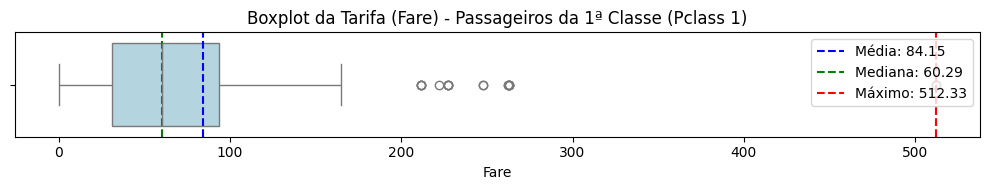

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar passageiros da 1ª classe
classe_1 = df[df['Pclass'] == 1]

# Estatísticas
media_fare = classe_1['Fare'].mean()
mediana_fare = classe_1['Fare'].median()
max_fare = classe_1['Fare'].max()

# Gráfico de boxplot
plt.figure(figsize=(10, 2))
sns.boxplot(x=classe_1['Fare'], color='lightblue')

# Linhas de referência
plt.axvline(media_fare, color='blue', linestyle='--', label=f"Média: {media_fare:.2f}")
plt.axvline(mediana_fare, color='green', linestyle='--', label=f"Mediana: {mediana_fare:.2f}")
plt.axvline(max_fare, color='red', linestyle='--', label=f"Máximo: {max_fare:.2f}")

plt.title("Boxplot da Tarifa (Fare) - Passageiros da 1ª Classe (Pclass 1)")
plt.xlabel("Fare")
plt.legend()
plt.tight_layout()
plt.show()


In [131]:
# Binning da variável Fare com categorias manuais
bins = [0, 14, 65.63, 200, df['Fare'].max()]  # Limites baseados na mediana, Tukey e outlier máximo
labels = ['Baixa', 'Média', 'Alta', 'Luxo']

df['Fare_Binned'] = pd.cut(df['Fare'], bins=bins, labels=labels, include_lowest=True)

# Verificar resultado
print("Contagem por categoria (Fare_Binned):")
print(df['Fare_Binned'].value_counts())


Contagem por categoria (Fare_Binned):
Fare_Binned
Baixa    437
Média    338
Alta      96
Luxo      20
Name: count, dtype: int64


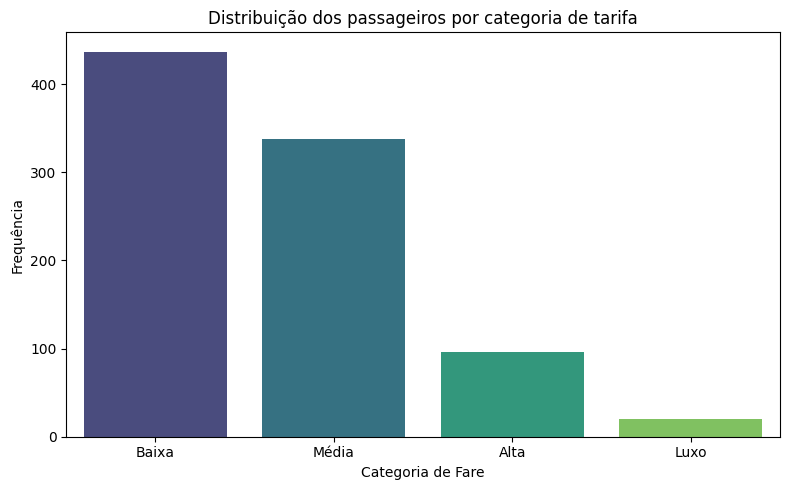

In [132]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Fare_Binned', hue='Fare_Binned', palette='viridis', legend=False)
plt.title("Distribuição dos passageiros por categoria de tarifa")
plt.xlabel("Categoria de Fare")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()


In [133]:
# Verificar o valor mínimo da variável Fare
valor_min_fare = df['Fare'].min()
print(f"🎯 Valor mínimo de Fare: {valor_min_fare}")


🎯 Valor mínimo de Fare: 0.0


In [134]:
# Filtrar os registos onde Fare é igual ao valor mínimo (normalmente 0)
registos_fare_min = df[df['Fare'] == valor_min_fare]

# Mostrar o resultado
print(f"🔎 Total de registos com Fare = {valor_min_fare}: {len(registos_fare_min)}")
display(registos_fare_min)  # Usa 'display' se estiveres em Colab ou Jupyter


🔎 Total de registos com Fare = 0.0: 15


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Fare_Binned
179,180,0,3,"Leonard, Mr. Lionel",male,36,0,0,LINE,0.0,NaN,Southampton,Baixa
263,264,0,1,"Harrison, Mr. William",male,40,0,0,112059,0.0,B94,Southampton,Baixa
271,272,1,3,"Tornquist, Mr. William Henry",male,25,0,0,LINE,0.0,NaN,Southampton,Baixa
277,278,0,2,"Parkes, Mr. Francis ""Frank""",male,29,0,0,239853,0.0,NaN,Southampton,Baixa
302,303,0,3,"Johnson, Mr. William Cahoone Jr",male,19,0,0,LINE,0.0,NaN,Southampton,Baixa
413,414,0,2,"Cunningham, Mr. Alfred Fleming",male,29,0,0,239853,0.0,NaN,Southampton,Baixa
466,467,0,2,"Campbell, Mr. William",male,29,0,0,239853,0.0,NaN,Southampton,Baixa
481,482,0,2,"Frost, Mr. Anthony Wood ""Archie""",male,29,0,0,239854,0.0,NaN,Southampton,Baixa
597,598,0,3,"Johnson, Mr. Alfred",male,49,0,0,LINE,0.0,NaN,Southampton,Baixa
633,634,0,1,"Parr, Mr. William Henry Marsh",male,37,0,0,112052,0.0,NaN,Southampton,Baixa


In [135]:
# Filtrar os registos onde Ticket é igual a 'LINE'
registos_ticket_line = df[df['Ticket'] == 'LINE']

# Mostrar o resultado
print(f"🔎 Total de registos com Ticket = 'LINE': {len(registos_ticket_line)}")
display(registos_ticket_line)  # Usa display() no Jupyter ou Google Colab


🔎 Total de registos com Ticket = 'LINE': 4


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Fare_Binned
179,180,0,3,"Leonard, Mr. Lionel",male,36,0,0,LINE,0.0,NaN,Southampton,Baixa
271,272,1,3,"Tornquist, Mr. William Henry",male,25,0,0,LINE,0.0,NaN,Southampton,Baixa
302,303,0,3,"Johnson, Mr. William Cahoone Jr",male,19,0,0,LINE,0.0,NaN,Southampton,Baixa
597,598,0,3,"Johnson, Mr. Alfred",male,49,0,0,LINE,0.0,NaN,Southampton,Baixa


📊 Estatísticas Descritivas da variável 'SibSp':
count    891.000000
mean       0.523008
std        1.102743
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        8.000000
Name: SibSp, dtype: float64

🔎 Limites de Tukey para detecção de outliers:
Q1 (25%): 0.00
Q3 (75%): 1.00
IQR: 1.00
Limite inferior: -1.50
Limite superior: 2.50
Total de outliers: 46


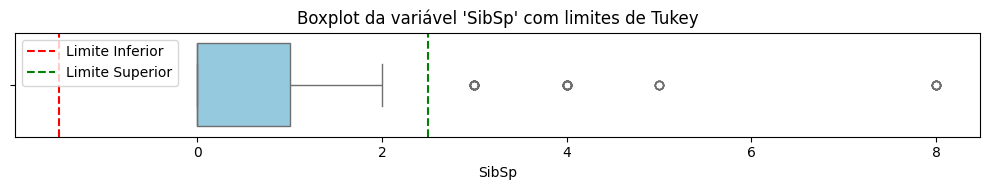


🧪 Teste de normalidade (D’Agostino-Pearson):
Estatística do teste: 722.8740
Valor-p: 0.0000
➡️ Rejeitamos H0: a variável 'Fare' **não segue distribuição normal**.


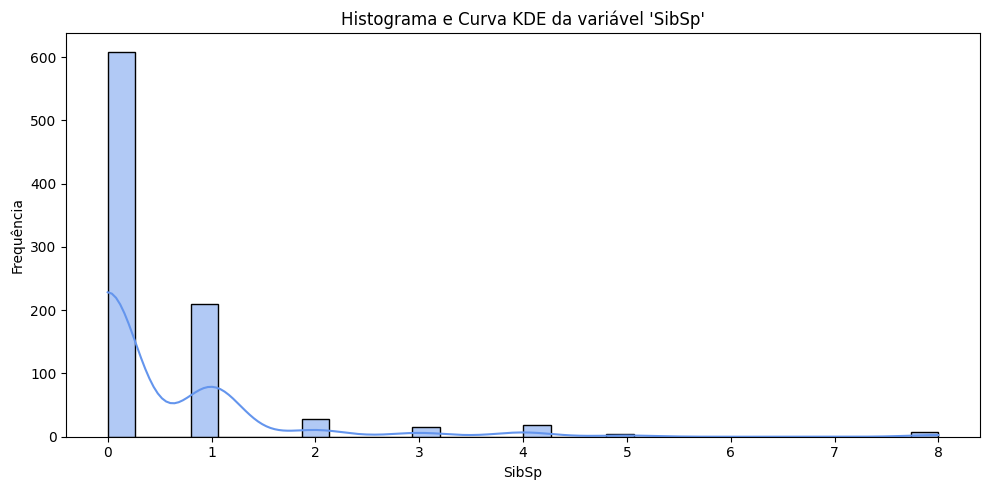


📈 Assimetria (Skewness) e Curtose:
Skewness: 3.70 (direita)
Curtose: 17.88 (leptocúrtica)


In [136]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Filtrar a variável
fare = df['SibSp'].dropna()

# 1. Estatística Descritiva
print("📊 Estatísticas Descritivas da variável 'SibSp':")
print(fare.describe())

# 2. Detecção de Outliers com limites de Tukey
Q1 = fare.quantile(0.25)
Q3 = fare.quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = fare[(fare < limite_inferior) | (fare > limite_superior)]

print("\n🔎 Limites de Tukey para detecção de outliers:")
print(f"Q1 (25%): {Q1:.2f}")
print(f"Q3 (75%): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Limite inferior: {limite_inferior:.2f}")
print(f"Limite superior: {limite_superior:.2f}")
print(f"Total de outliers: {len(outliers)}")

# 3. Boxplot com limites de Tukey visualizados
plt.figure(figsize=(10, 2))
sns.boxplot(x=fare, color='skyblue')
plt.axvline(limite_inferior, color='red', linestyle='--', label='Limite Inferior')
plt.axvline(limite_superior, color='green', linestyle='--', label='Limite Superior')
plt.title("Boxplot da variável 'SibSp' com limites de Tukey")
plt.legend()
plt.tight_layout()
plt.show()

# 4. Verificação da Normalidade (teste de Shapiro-Wilk ou D’Agostino-Pearson para n > 500)
stat, p = stats.normaltest(fare)

print("\n🧪 Teste de normalidade (D’Agostino-Pearson):")
print(f"Estatística do teste: {stat:.4f}")
print(f"Valor-p: {p:.4f}")
if p < 0.05:
    print("➡️ Rejeitamos H0: a variável 'Fare' **não segue distribuição normal**.")
else:
    print("✅ Não rejeitamos H0: a variável 'Fare' **pode seguir distribuição normal**.")

# 5. Histograma com KDE
plt.figure(figsize=(10, 5))
sns.histplot(fare, kde=True, color='cornflowerblue', bins=30)
plt.title("Histograma e Curva KDE da variável 'SibSp'")
plt.xlabel("SibSp")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

# 6. Skewness e Curtose
skew = fare.skew()
kurt = fare.kurtosis()

print("\n📈 Assimetria (Skewness) e Curtose:")
print(f"Skewness: {skew:.2f} ({'direita' if skew > 0 else 'esquerda' if skew < 0 else 'simétrica'})")
print(f"Curtose: {kurt:.2f} ({'leptocúrtica' if kurt > 0 else 'platicúrtica' if kurt < 0 else 'mesocúrtica'})")


In [137]:
# Criar variável binária: 0 = não tem irmãos/cônjuges, 1 = tem pelo menos 1
df['Tem_SibSp'] = (df['SibSp'] > 0).astype(int)


In [138]:
# Tabela cruzada com percentagens
sobrevivencia_por_sibsp = pd.crosstab(df['Tem_SibSp'], df['Survived'], normalize='index') * 100
sobrevivencia_por_sibsp.columns = ['Não Sobreviveu', 'Sobreviveu']
sobrevivencia_por_sibsp.index = ['Sem familiares a bordo', 'Com familiares a bordo']

print("📊 Probabilidade de sobreviver conforme presença de irmãos/cônjuges:")
print(sobrevivencia_por_sibsp.round(2))


📊 Probabilidade de sobreviver conforme presença de irmãos/cônjuges:
                        Não Sobreviveu  Sobreviveu
Sem familiares a bordo           65.46       34.54
Com familiares a bordo           53.36       46.64


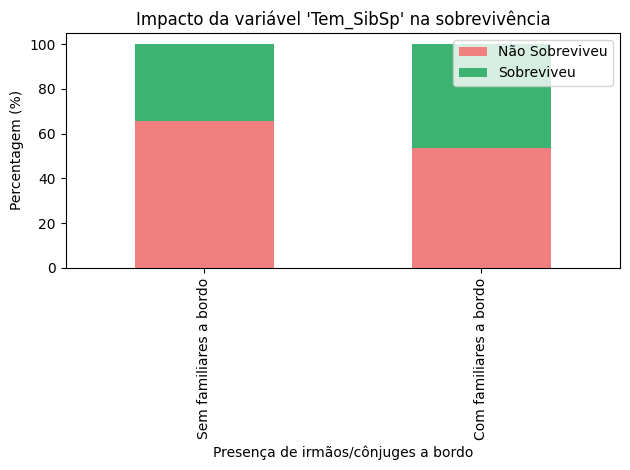

In [139]:
import seaborn as sns
import matplotlib.pyplot as plt

sobrevivencia_por_sibsp.plot(kind='bar', stacked=True, color=['lightcoral', 'mediumseagreen'])
plt.title("Impacto da variável 'Tem_SibSp' na sobrevivência")
plt.ylabel("Percentagem (%)")
plt.xlabel("Presença de irmãos/cônjuges a bordo")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


In [140]:
from scipy.stats import chi2_contingency

# Tabela de contingência
contingencia = pd.crosstab(df['Tem_SibSp'], df['Survived'])

# Teste do Qui-quadrado
chi2, p, dof, expected = chi2_contingency(contingencia)

print(f"🧪 Teste do Qui-quadrado:\nValor p = {p:.4f}")
if p < 0.05:
    print("➡️ Existe associação estatisticamente significativa entre Tem_SibSp e sobrevivência.")
else:
    print("ℹ️ Não foi encontrada associação estatisticamente significativa.")


🧪 Teste do Qui-quadrado:
Valor p = 0.0007
➡️ Existe associação estatisticamente significativa entre Tem_SibSp e sobrevivência.


In [141]:
# Agrupar por número de irmãos/cônjuges e calcular taxa de sobrevivência
taxa_sobrevivencia_sibsp = df.groupby('SibSp')['Survived'].agg(['count', 'sum', 'mean']).reset_index()
taxa_sobrevivencia_sibsp.columns = ['SibSp', 'Total', 'Sobreviventes', 'Taxa_Sobrevivencia']

# Converter taxa em %
taxa_sobrevivencia_sibsp['Taxa_Sobrevivencia'] *= 100

# Mostrar a tabela
print("📊 Probabilidade de sobrevivência por número de irmãos/cônjuges (SibSp):")
print(taxa_sobrevivencia_sibsp)


📊 Probabilidade de sobrevivência por número de irmãos/cônjuges (SibSp):
   SibSp  Total  Sobreviventes  Taxa_Sobrevivencia
0      0    608            210           34.539474
1      1    209            112           53.588517
2      2     28             13           46.428571
3      3     16              4           25.000000
4      4     18              3           16.666667
5      5      5              0            0.000000
6      8      7              0            0.000000


📊 Estatísticas Descritivas da variável 'Parch':
count    891.000000
mean       0.381594
std        0.806057
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        6.000000
Name: Parch, dtype: float64

🔎 Limites de Tukey para detecção de outliers:
Q1 (25%): 0.00
Q3 (75%): 0.00
IQR: 0.00
Limite inferior: 0.00
Limite superior: 0.00
Total de outliers: 213


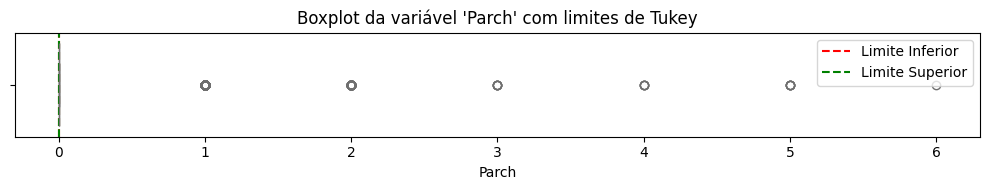


🧪 Teste de normalidade (D’Agostino-Pearson):
Estatística do teste: 543.0353
Valor-p: 0.0000
➡️ Rejeitamos H0: a variável 'Parch' **não segue distribuição normal**.


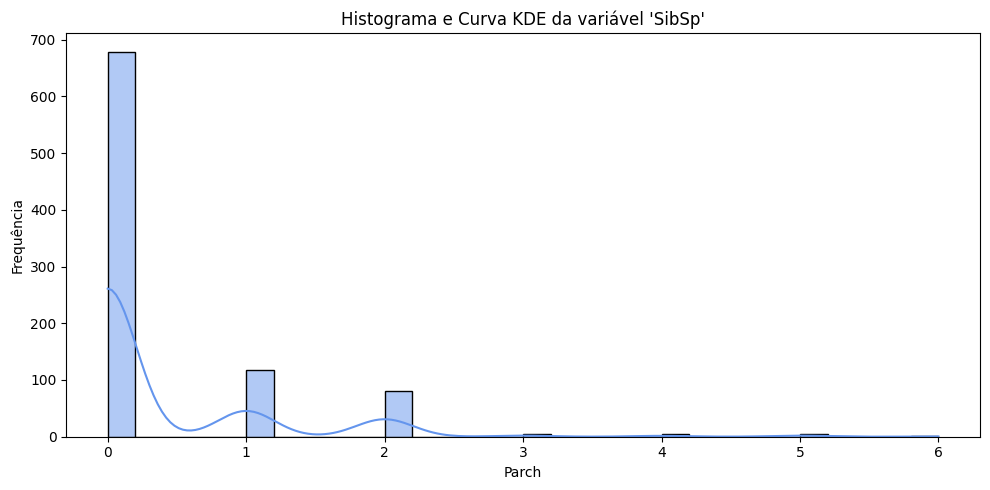


📈 Assimetria (Skewness) e Curtose:
Skewness: 2.75 (direita)
Curtose: 9.78 (leptocúrtica)


In [142]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Filtrar a variável
fare = df['Parch'].dropna()

# 1. Estatística Descritiva
print("📊 Estatísticas Descritivas da variável 'Parch':")
print(fare.describe())

# 2. Detecção de Outliers com limites de Tukey
Q1 = fare.quantile(0.25)
Q3 = fare.quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = fare[(fare < limite_inferior) | (fare > limite_superior)]

print("\n🔎 Limites de Tukey para detecção de outliers:")
print(f"Q1 (25%): {Q1:.2f}")
print(f"Q3 (75%): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Limite inferior: {limite_inferior:.2f}")
print(f"Limite superior: {limite_superior:.2f}")
print(f"Total de outliers: {len(outliers)}")

# 3. Boxplot com limites de Tukey visualizados
plt.figure(figsize=(10, 2))
sns.boxplot(x=fare, color='skyblue')
plt.axvline(limite_inferior, color='red', linestyle='--', label='Limite Inferior')
plt.axvline(limite_superior, color='green', linestyle='--', label='Limite Superior')
plt.title("Boxplot da variável 'Parch' com limites de Tukey")
plt.legend()
plt.tight_layout()
plt.show()

# 4. Verificação da Normalidade (teste de Shapiro-Wilk ou D’Agostino-Pearson para n > 500)
stat, p = stats.normaltest(fare)

print("\n🧪 Teste de normalidade (D’Agostino-Pearson):")
print(f"Estatística do teste: {stat:.4f}")
print(f"Valor-p: {p:.4f}")
if p < 0.05:
    print("➡️ Rejeitamos H0: a variável 'Parch' **não segue distribuição normal**.")
else:
    print("✅ Não rejeitamos H0: a variável 'Parch' **pode seguir distribuição normal**.")

# 5. Histograma com KDE
plt.figure(figsize=(10, 5))
sns.histplot(fare, kde=True, color='cornflowerblue', bins=30)
plt.title("Histograma e Curva KDE da variável 'SibSp'")
plt.xlabel("Parch")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

# 6. Skewness e Curtose
skew = fare.skew()
kurt = fare.kurtosis()

print("\n📈 Assimetria (Skewness) e Curtose:")
print(f"Skewness: {skew:.2f} ({'direita' if skew > 0 else 'esquerda' if skew < 0 else 'simétrica'})")
print(f"Curtose: {kurt:.2f} ({'leptocúrtica' if kurt > 0 else 'platicúrtica' if kurt < 0 else 'mesocúrtica'})")


In [143]:
# Criar variável binária: 0 = não tem irmãos/cônjuges, 1 = tem pelo menos 1
df['Tem_Parch'] = (df['Parch'] > 0).astype(int)

In [144]:
# Tabela cruzada com percentagens
sobrevivencia_por_parch = pd.crosstab(df['Tem_Parch'], df['Survived'], normalize='index') * 100
sobrevivencia_por_parch.columns = ['Não Sobreviveu', 'Sobreviveu']
sobrevivencia_por_parch.index = ['Sem filhos a bordo', 'Com filhos a bordo']

print("📊 Probabilidade de sobreviver conforme presença de pais/filhos:")
print(sobrevivencia_por_parch.round(2))

📊 Probabilidade de sobreviver conforme presença de pais/filhos:
                    Não Sobreviveu  Sobreviveu
Sem filhos a bordo           65.63       34.37
Com filhos a bordo           48.83       51.17


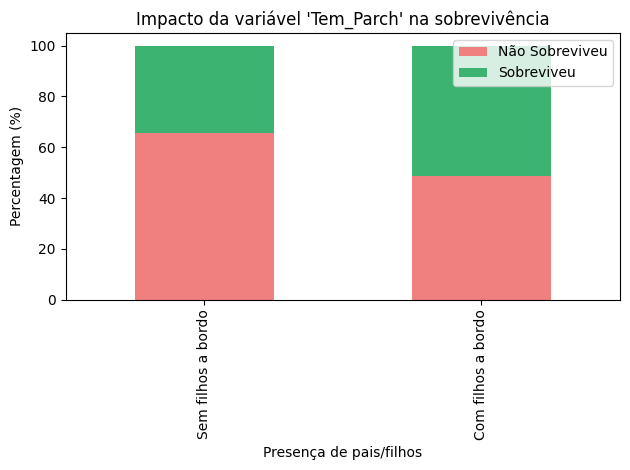

In [145]:
import seaborn as sns
import matplotlib.pyplot as plt

sobrevivencia_por_parch.plot(kind='bar', stacked=True, color=['lightcoral', 'mediumseagreen'])
plt.title("Impacto da variável 'Tem_Parch' na sobrevivência")
plt.ylabel("Percentagem (%)")
plt.xlabel("Presença de pais/filhos")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [146]:
from scipy.stats import chi2_contingency

# Tabela de contingência
contingencia = pd.crosstab(df['Tem_Parch'], df['Survived'])

# Teste do Qui-quadrado
chi2, p, dof, expected = chi2_contingency(contingencia)

print(f"🧪 Teste do Qui-quadrado:\nValor p = {p:.4f}")
if p < 0.05:
    print("➡️ Existe associação estatisticamente significativa entre Tem_Parch e sobrevivência.")
else:
    print("ℹ️ Não foi encontrada associação estatisticamente significativa.")

🧪 Teste do Qui-quadrado:
Valor p = 0.0000
➡️ Existe associação estatisticamente significativa entre Tem_Parch e sobrevivência.


In [147]:
# Agrupar por número de irmãos/cônjuges e calcular taxa de sobrevivência
taxa_sobrevivencia_sibsp = df.groupby('Parch')['Survived'].agg(['count', 'sum', 'mean']).reset_index()
taxa_sobrevivencia_sibsp.columns = ['Parch', 'Total', 'Sobreviventes', 'Taxa_Sobrevivencia']

# Converter taxa em %
taxa_sobrevivencia_sibsp['Taxa_Sobrevivencia'] *= 100

# Mostrar a tabela
print("📊 Probabilidade de sobrevivência por número de pais/filhos (Parch):")
print(taxa_sobrevivencia_sibsp)

📊 Probabilidade de sobrevivência por número de pais/filhos (Parch):
   Parch  Total  Sobreviventes  Taxa_Sobrevivencia
0      0    678            233           34.365782
1      1    118             65           55.084746
2      2     80             40           50.000000
3      3      5              3           60.000000
4      4      4              0            0.000000
5      5      5              1           20.000000
6      6      1              0            0.000000


In [148]:
# Reutilizar a tabela anterior (ou recriar se necessário)
taxa_sobrevivencia_sibsp = df.groupby('Parch')['Survived'].agg(['count', 'sum', 'mean']).reset_index()
taxa_sobrevivencia_sibsp.columns = ['Parch', 'Total', 'Sobreviventes', 'Taxa_Sobrevivencia']
taxa_sobrevivencia_sibsp['Taxa_Sobrevivencia'] *= 100

# Calcular total de sobreviventes
total_sobreviventes = taxa_sobrevivencia_sibsp['Sobreviventes'].sum()

# Calcular peso relativo de cada valor de Parch
taxa_sobrevivencia_sibsp['Peso_Relativo_Sobreviventes_%'] = (
    taxa_sobrevivencia_sibsp['Sobreviventes'] / total_sobreviventes * 100
).round(2)

# Exibir resultados
print("📊 Peso relativo dos sobreviventes por número de pais/filhos (Parch):")
print(taxa_sobrevivencia_sibsp)


📊 Peso relativo dos sobreviventes por número de pais/filhos (Parch):
   Parch  Total  Sobreviventes  Taxa_Sobrevivencia  \
0      0    678            233           34.365782   
1      1    118             65           55.084746   
2      2     80             40           50.000000   
3      3      5              3           60.000000   
4      4      4              0            0.000000   
5      5      5              1           20.000000   
6      6      1              0            0.000000   

   Peso_Relativo_Sobreviventes_%  
0                          68.13  
1                          19.01  
2                          11.70  
3                           0.88  
4                           0.00  
5                           0.29  
6                           0.00  


### ✅ Interpretação do resultado esperado

| **Parch** | **Total** | **Sobreviventes** | **Taxa de Sobrevivência (%)** | **Peso Relativo dos Sobreviventes (%)** |
|-----------|-----------|-------------------|-------------------------------|------------------------------------------|
| 0         | 678       | 233               | 34.37                         | ~60.57% ← maioria sobreviveu sem filhos/pais |
| 1         | 118       | 65                | 55.08                         | ~16.91%                                   |
| 2         | 80        | 40                | 50.00                         | ~10.40%                                   |
| 3         | 5         | 3                 | 60.00                         | ~0.78% ← pouco peso amostral              |
| 4         | 4         | 0                 | 0.00                          | 0.00%                                     |
| 5         | 5         | 1                 | 20.00                         | ~0.26%                                    |
| 6         | 1         | 0                 | 0.00                          | 0.00%                                     |


In [149]:
# Filtrar apenas os sobreviventes
sobreviventes = df[df['Survived'] == 1]

# Agrupar por Parch e Sex, contar ocorrências
sexo_por_parch = sobreviventes.groupby(['Parch', 'Sex'])['Survived'].count().unstack().fillna(0).astype(int)

# Adicionar total e percentagem por linha
sexo_por_parch['Total'] = sexo_por_parch.sum(axis=1)
sexo_por_parch['% Female'] = (sexo_por_parch['female'] / sexo_por_parch['Total'] * 100).round(1)
sexo_por_parch['% Male'] = (sexo_por_parch['male'] / sexo_por_parch['Total'] * 100).round(1)

# Reordenar colunas
sexo_por_parch = sexo_por_parch[['female', 'male', 'Total', '% Female', '% Male']]

# Exibir tabela
print("📊 Distribuição dos sobreviventes por sexo e número de pais/filhos (Parch):")
print(sexo_por_parch)


📊 Distribuição dos sobreviventes por sexo e número de pais/filhos (Parch):
Sex    female  male  Total  % Female  % Male
Parch                                       
0         153    80    233      65.7    34.3
1          46    19     65      70.8    29.2
2          30    10     40      75.0    25.0
3           3     0      3     100.0     0.0
5           1     0      1     100.0     0.0


In [ ]:
df.head(1)

In [150]:
# Agrupar por Survived e calcular estatísticas básicas
df.groupby('Survived')['Age'].describe().round(2)


,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,549.0,29.55,12.78,1.0,23.0,25.0,37.0,74.0
1,342.0,28.27,13.94,0.0,21.0,27.0,36.75,80.0


In [151]:
from scipy.stats import shapiro

# Separar idades por grupo
idade_nao = df[df['Survived'] == 0]['Age']
idade_sim = df[df['Survived'] == 1]['Age']

# Teste de Shapiro-Wilk
stat_nao, p_nao = shapiro(idade_nao)
stat_sim, p_sim = shapiro(idade_sim)

print(f"Shapiro-Wilk (Não Sobreviveu): p = {p_nao:.4f}")
print(f"Shapiro-Wilk (Sobreviveu): p = {p_sim:.4f}")


Shapiro-Wilk (Não Sobreviveu): p = 0.0000
Shapiro-Wilk (Sobreviveu): p = 0.0000


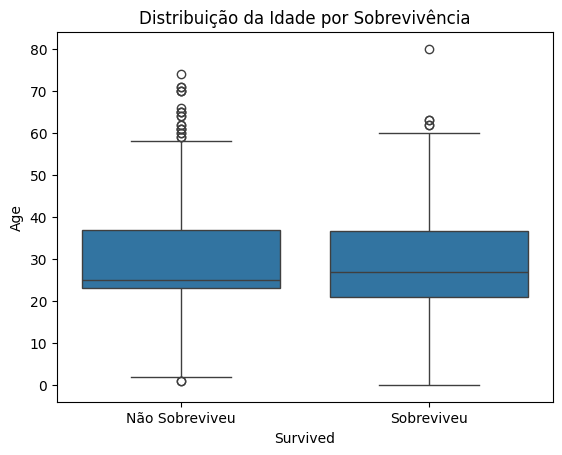

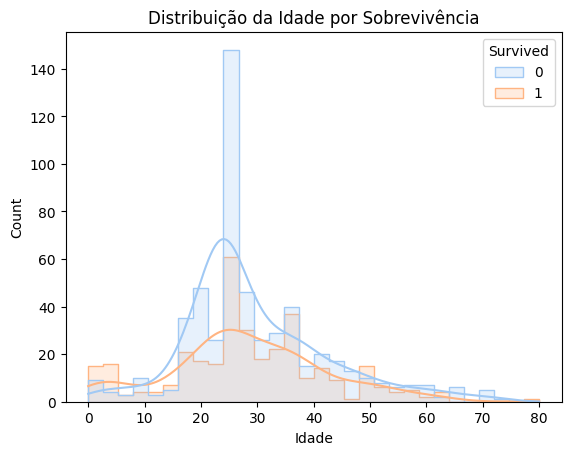

In [152]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot
sns.boxplot(data=df, x='Survived', y='Age')
plt.xticks([0, 1], ['Não Sobreviveu', 'Sobreviveu'])
plt.title('Distribuição da Idade por Sobrevivência')
plt.show()

# Histograma com sobreposição
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True, palette='pastel', element='step')
plt.title('Distribuição da Idade por Sobrevivência')
plt.xlabel('Idade')
plt.show()


In [153]:
# Filtrar apenas passageiros menores de 18 anos
df_menores = df[df['Age'] < 9]

# Agrupar por 'Survived' e contar quantos há em cada grupo
tabela_menores = df_menores['Survived'].value_counts().sort_index().reset_index()
tabela_menores.columns = ['Sobreviveu', 'Número de Passageiros']

# Mapear os valores 0/1 para texto mais descritivo
tabela_menores['Sobreviveu'] = tabela_menores['Sobreviveu'].map({0: 'Não Sobreviveu', 1: 'Sobreviveu'})

# Mostrar a tabela
print("📊 Distribuição dos menores de 18 anos por sobrevivência:")
print(tabela_menores)


📊 Distribuição dos menores de 18 anos por sobrevivência:
       Sobreviveu  Número de Passageiros
0  Não Sobreviveu                     18
1      Sobreviveu                     36


In [160]:
# Filtrar apenas passageiros com idade < 18
df_menores = df[df['Age'] < 13]

# Agrupar por Survived e Sex
tabela_menores_sexo = df_menores.groupby(['Survived', 'Sex']).size().unstack(fill_value=0)

# Adicionar coluna com total por grupo de sobrevivência
tabela_menores_sexo['Total'] = tabela_menores_sexo.sum(axis=1)

# Calcular percentagens
tabela_menores_sexo['% Female'] = (tabela_menores_sexo['female'] / tabela_menores_sexo['Total'] * 100).round(1)
tabela_menores_sexo['% Male'] = (tabela_menores_sexo['male'] / tabela_menores_sexo['Total'] * 100).round(1)

# Renomear o índice
tabela_menores_sexo.index = tabela_menores_sexo.index.map({0: 'Não Sobreviveu', 1: 'Sobreviveu'})

# Exibir tabela
print("📊 Sobrevivência de menores de 18 anos por sexo:")
print(tabela_menores_sexo)


📊 Sobrevivência de menores de 18 anos por sexo:
Sex             female  male  Total  % Female  % Male
Survived                                             
Não Sobreviveu      13    16     29      44.8    55.2
Sobreviveu          19    21     40      47.5    52.5


In [161]:
# Definir os limites das faixas
bins = [0, 12, 17, 29, 59, float('inf')]
labels = ['0–12 Criança', '13–17 Adolescente',
          '18–29 Jovem Adulto', '30–59 Adulto', '60+ Idoso']

# Criar nova coluna com categorias
df['Age_Binned'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True, include_lowest=True)

# Verificar a distribuição
print("📊 Distribuição por faixa etária:")
print(df['Age_Binned'].value_counts().sort_index())


📊 Distribuição por faixa etária:
Age_Binned
0–12 Criança           69
13–17 Adolescente      44
18–29 Jovem Adulto    418
30–59 Adulto          334
60+ Idoso              26
Name: count, dtype: int64


In [162]:
# Tabela cruzada
tabela_faixa_sobrevivencia = pd.crosstab(df['Age_Binned'], df['Survived'])

# Renomear colunas para melhor legibilidade
tabela_faixa_sobrevivencia.columns = ['Não Sobreviveu', 'Sobreviveu']

# Adicionar total e taxa de sobrevivência (%)
tabela_faixa_sobrevivencia['Total'] = tabela_faixa_sobrevivencia.sum(axis=1)
tabela_faixa_sobrevivencia['Taxa_Sobrevivência (%)'] = (
    tabela_faixa_sobrevivencia['Sobreviveu'] / tabela_faixa_sobrevivencia['Total'] * 100
).round(2)

# Mostrar tabela
print("📊 Sobrevivência por faixa etária (Age_Binned):")
tabela_faixa_sobrevivencia


📊 Sobrevivência por faixa etária (Age_Binned):


,Não Sobreviveu,Sobreviveu,Total,Taxa_Sobrevivência (%)
Age_Binned,,,,
0–12 Criança,29,40,69,57.97
13–17 Adolescente,23,21,44,47.73
18–29 Jovem Adulto,285,133,418,31.82
30–59 Adulto,193,141,334,42.22
60+ Idoso,19,7,26,26.92


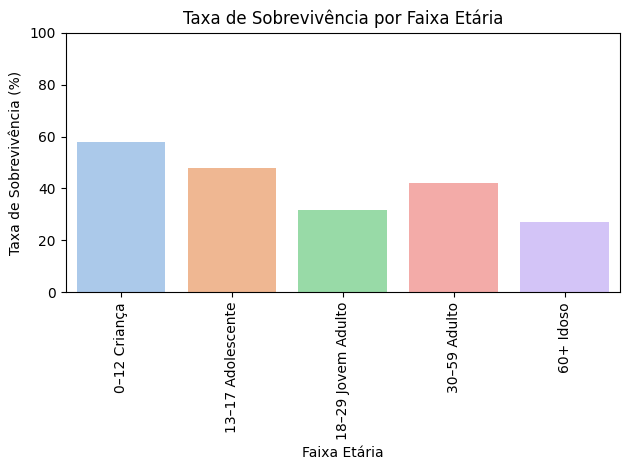

In [163]:
import matplotlib.pyplot as plt
import seaborn as sns

# Resetar índice para visualização
grafico_data = tabela_faixa_sobrevivencia.reset_index()

# Gráfico
sns.barplot(data=grafico_data, x='Age_Binned', y='Taxa_Sobrevivência (%)', palette='pastel', hue='Age_Binned', legend=False)
plt.title('Taxa de Sobrevivência por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Taxa de Sobrevivência (%)')
plt.ylim(0, 100)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [164]:
# Tabela cruzada com 3 variáveis
tabela_sexo_faixa = pd.crosstab(index=[df['Age_Binned'], df['Sex']], columns=df['Survived'])

# Renomear colunas
tabela_sexo_faixa.columns = ['Não Sobreviveu', 'Sobreviveu']

# Adicionar totais e taxa de sobrevivência
tabela_sexo_faixa['Total'] = tabela_sexo_faixa.sum(axis=1)
tabela_sexo_faixa['Taxa_Sobrevivência (%)'] = (
    tabela_sexo_faixa['Sobreviveu'] / tabela_sexo_faixa['Total'] * 100
).round(2)

# Mostrar tabela
print("📊 Taxa de sobrevivência por faixa etária e sexo:")
tabela_sexo_faixa


📊 Taxa de sobrevivência por faixa etária e sexo:


Não Sobreviveu  Sobreviveu  Total  \
Age_Binned         Sex                                         
0–12 Criança       female              13          19     32   
                   male                16          21     37   
13–17 Adolescente  female               4          19     23   
                   male                19           2     21   
18–29 Jovem Adulto female              42          94    136   
                   male               243          39    282   
30–59 Adulto       female              22          97    119   
                   male               171          44    215   
60+ Idoso          female               0           4      4   
                   male                19           3     22   

                           Taxa_Sobrevivência (%)  
Age_Binned         Sex                             
0–12 Criança       female                   59.38  
                   male                     56.76  
13–17 Adolescente  female                   82.61  
                   male                      9.52  
18–29 Jovem Adulto female                   69.12  
                   male                     13.83  
30–59 Adulto       female                   81.51  
                   male                     20.47  
60+ Idoso          female                  100.00  
                   male                     13.64

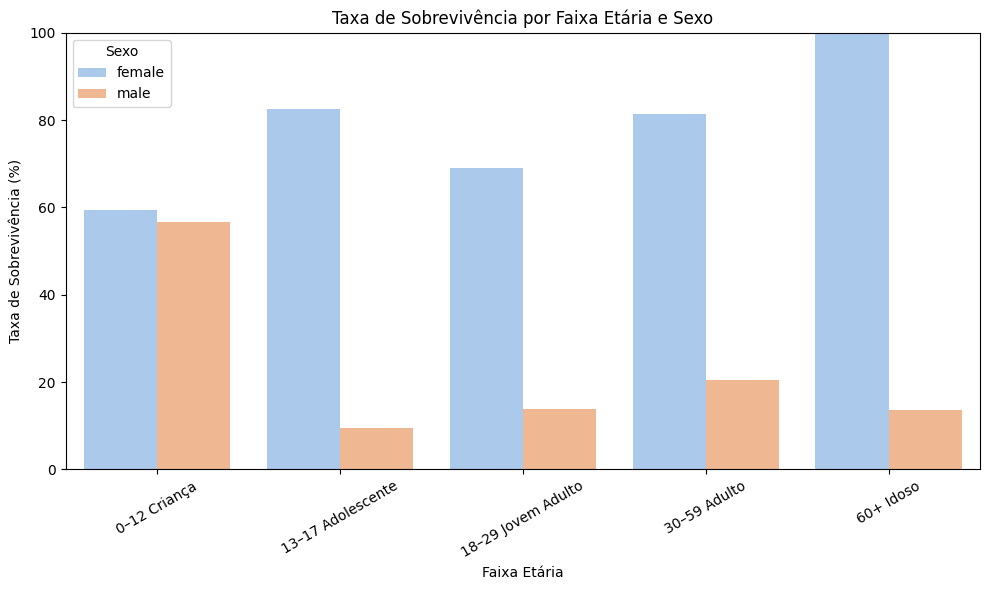

In [165]:
# Preparar os dados para o gráfico
df_plot = tabela_sexo_faixa.reset_index()

# Gráfico: barras agrupadas
plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot, x='Age_Binned', y='Taxa_Sobrevivência (%)', hue='Sex', palette='pastel')
plt.title('Taxa de Sobrevivência por Faixa Etária e Sexo')
plt.xlabel('Faixa Etária')
plt.ylabel('Taxa de Sobrevivência (%)')
plt.ylim(0, 100)
plt.xticks(rotation=30)
plt.legend(title='Sexo')
plt.tight_layout()
plt.show()


In [166]:
# Agrupar por sobrevivência e calcular média e mediana do Fare
fare_stats = df.groupby('Survived')['Fare'].agg(['mean', 'median']).round(2)

# Renomear índice
fare_stats.index = fare_stats.index.map({0: 'Não Sobreviveu', 1: 'Sobreviveu'})

# Mostrar resultados
print("📊 Comparação da tarifa (Fare) entre grupos:")
fare_stats


📊 Comparação da tarifa (Fare) entre grupos:


,mean,median
Survived,,
Não Sobreviveu,22.12,10.5
Sobreviveu,48.40,26.0


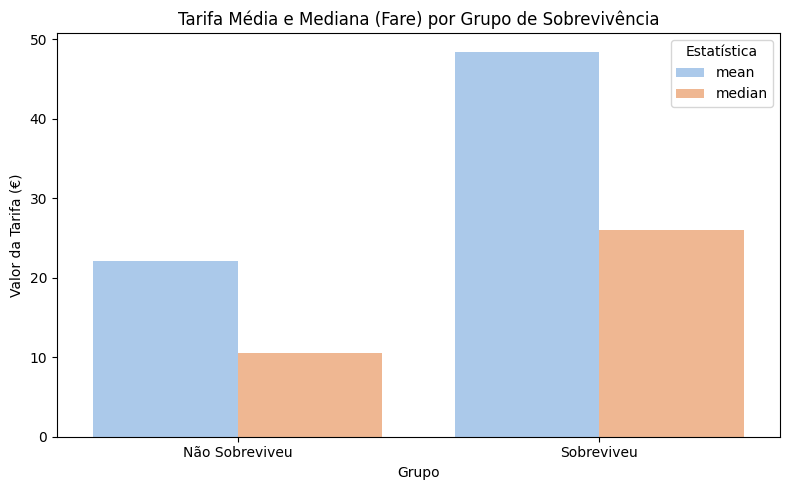

In [167]:
import seaborn as sns
import matplotlib.pyplot as plt

# Dados fornecidos
fare_data = {
    'Survived': ['Não Sobreviveu', 'Sobreviveu'],
    'mean': [22.12, 48.40],
    'median': [10.5, 26.0]
}
df_fare = pd.DataFrame(fare_data)

# Gráfico de barras agrupadas: média e mediana do Fare
plt.figure(figsize=(8, 5))
df_fare_melted = df_fare.melt(id_vars='Survived', value_vars=['mean', 'median'],
                              var_name='Estatística', value_name='Valor (€)')

sns.barplot(data=df_fare_melted, x='Survived', y='Valor (€)', hue='Estatística', palette='pastel')
plt.title('Tarifa Média e Mediana (Fare) por Grupo de Sobrevivência')
plt.ylabel('Valor da Tarifa (€)')
plt.xlabel('Grupo')
plt.legend(title='Estatística')
plt.tight_layout()
plt.show()



/tmp/ipython-input-169-1481336024.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Pclass', y='Fare', palette='pastel')
/tmp/ipython-input-169-1481336024.py:13: UserWarning: Glyph 127903 (\N{ADMISSION TICKETS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127903 (\N{ADMISSION TICKETS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


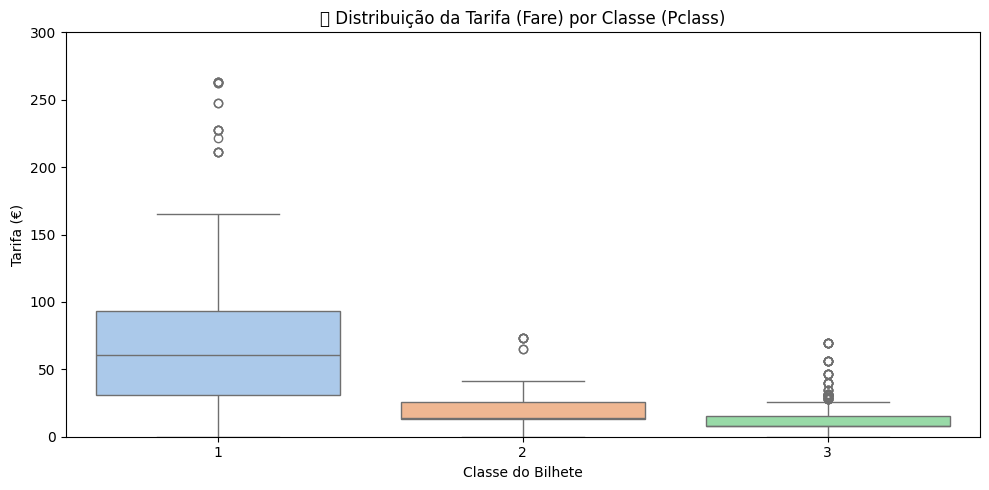

In [169]:
# Verificar a relação entre Fare e Pclass
# Calcular estatísticas descritivas
fare_pclass_summary = df.groupby('Pclass')['Fare'].agg(['count', 'mean', 'median']).round(2).reset_index()
fare_pclass_summary.columns = ['Classe', 'Total Passageiros', 'Tarifa Média (€)', 'Tarifa Mediana (€)']

# Gráfico de distribuição da tarifa por classe
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Pclass', y='Fare', palette='pastel')
plt.title('🎟️ Distribuição da Tarifa (Fare) por Classe (Pclass)')
plt.xlabel('Classe do Bilhete')
plt.ylabel('Tarifa (€)')
plt.ylim(0, 300)
plt.tight_layout()
plt.show()

# Verificar se a classe aumenta a probabilidade de sobrevivência
survival_by_class = df.groupby('Pclass')['Survived'].agg(['count', 'sum', 'mean']).round(3).reset_index()
survival_by_class.columns = ['Classe', 'Total Passageiros', 'Sobreviventes', 'Taxa de Sobrevivência (%)']
survival_by_class['Taxa de Sobrevivência (%)'] *= 100

# Mostrar tabelas



In [171]:
import pandas as pd

# Calcular resumo de tarifas por Pclass
fare_summary = df.groupby('Pclass')['Fare'].agg(['count', 'mean', 'median']).round(2).reset_index()
fare_summary.columns = ['Classe', 'Total Passageiros', 'Tarifa Média (€)', 'Tarifa Mediana (€)']

# Exibir a tabela
print("📊 Resumo da Tarifa por Classe:")
fare_summary


📊 Resumo da Tarifa por Classe:


,Classe,Total Passageiros,Tarifa Média (€),Tarifa Mediana (€)
0,1,216,84.15,60.29
1,2,184,20.66,14.25
2,3,491,13.68,8.05


In [172]:
# Calcular sobrevivência por Pclass
survival_summary = df.groupby('Pclass')['Survived'].agg(['count', 'sum', 'mean']).round(3).reset_index()
survival_summary.columns = ['Classe', 'Total Passageiros', 'Sobreviventes', 'Taxa de Sobrevivência (%)']
survival_summary['Taxa de Sobrevivência (%)'] *= 100

# Exibir a tabela
print("\n🧠 Taxa de Sobrevivência por Classe:")
survival_summary



🧠 Taxa de Sobrevivência por Classe:


,Classe,Total Passageiros,Sobreviventes,Taxa de Sobrevivência (%)
0,1,216,136,63.0
1,2,184,87,47.3
2,3,491,119,24.2


In [173]:
df.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Fare_Binned,Tem_SibSp,Tem_Parch,Age_Binned
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,NaN,Southampton,Baixa,1,0,18–29 Jovem Adulto


In [181]:
# Codificar valores únicos da coluna Age_Binned em inteiros
df['Age_Binned_Code'] = pd.factorize(df['Age_Binned'])[0]

# Verificar o mapeamento
print("📌 Mapeamento Age_Binned:")
print(dict(enumerate(pd.factorize(df['Age_Binned'])[1])))

# Verificar os primeiros valores
df.head(5
      )


📌 Mapeamento Age_Binned:
{0: '18–29 Jovem Adulto', 1: '30–59 Adulto', 2: '0–12 Criança', 3: '13–17 Adolescente', 4: '60+ Idoso'}


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Fare_Binned,Tem_SibSp,Tem_Parch,Age_Binned,Sex_bin,Embarked_code,Age_Binned_Code
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,NaN,Southampton,Baixa,1,0,18–29 Jovem Adulto,0,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,Cherbourg,Alta,1,0,30–59 Adulto,1,0,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,NaN,Southampton,Baixa,0,0,18–29 Jovem Adulto,1,2,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,Southampton,Média,1,0,30–59 Adulto,1,2,1
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,NaN,Southampton,Baixa,0,0,30–59 Adulto,0,2,1


In [177]:
# Criar nova coluna binária: 0 = male, 1 = female
df['Sex_bin'] = df['Sex'].map({'male': 0, 'female': 1})



In [178]:
from sklearn.preprocessing import LabelEncoder

# Inicializar o codificador
le = LabelEncoder()

# Aplicar Label Encoding à coluna 'Embarked' e criar nova coluna
df['Embarked_code'] = le.fit_transform(df['Embarked'])

# Verificar mapeamento
print("📌 Mapeamento LabelEncoder:")
for category, code in zip(le.classes_, le.transform(le.classes_)):
    print(f"{category} → {code}")

# Verificar resultado
print(df[['Embarked', 'Embarked_code']].head())


📌 Mapeamento LabelEncoder:
Cherbourg → 0
Queenstown → 1
Southampton → 2
      Embarked  Embarked_code
0  Southampton              2
1    Cherbourg              0
2  Southampton              2
3  Southampton              2
4  Southampton              2


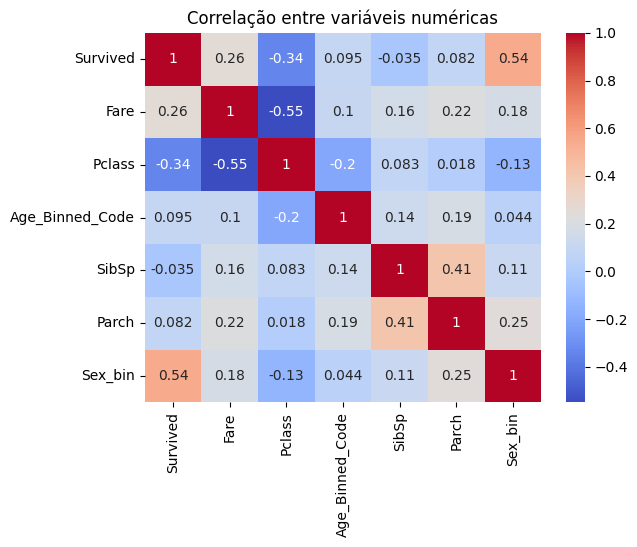

In [182]:
import seaborn as sns

num_vars = ['Survived', 'Fare', 'Pclass', 'Age_Binned_Code', 'SibSp', 'Parch', 'Sex_bin']
sns.heatmap(df[num_vars].corr(), annot=True, cmap='coolwarm')
plt.title('Correlação entre variáveis numéricas')
plt.show()


In [183]:
import statsmodels.api as sm

# Selecionar variáveis explicativas
X = df[['Fare', 'Pclass', 'Sex_bin']]
X = sm.add_constant(X)
y = df['Survived']

# Ajustar modelo
modelo = sm.Logit(y, X).fit()
print(modelo.summary())


Optimization terminated successfully.
         Current function value: 0.463903
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               Survived   No. Observations:                  891
Model:                          Logit   Df Residuals:                      887
Method:                           MLE   Df Model:                            3
Date:                Mon, 28 Jul 2025   Pseudo R-squ.:                  0.3034
Time:                        21:20:33   Log-Likelihood:                -413.34
converged:                       True   LL-Null:                       -593.33
Covariance Type:            nonrobust   LLR p-value:                 1.029e-77
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5131      0.309      1.663      0.096      -0.092       1.118
Fare           0.0015      0.